# Hybrid Latency Lab — WAN vs LAN comparison

This notebook is the **analytical companion** to the lab. It reads the
raw CSVs produced by `run_experiments.sh` and `latency_probe.py` from
**both** measurement points and compares them side-by-side:

| Env | Where it runs | Network to PG |
| --- | --- | --- |
| `onprem-wan` | Arc-onboarded "on-prem" VM in the on-prem VNet, reaching PG via vWAN, with `tc netem 80 ms ± 5 ms` injected on egress | simulated WAN ≈ 80 ms RTT |
| `spoke-lan` | VM inside the same VNet as PG | LAN ≈ sub-millisecond RTT |

Same scripts. Same database. Same dataset (5000 items, 500 processed per
run). The only thing that changes is the network path. That's exactly
what isolates the *WAN tax* on chatty round-trips.

Files used:
- `experiments.csv` — 6 runs per env (3 chatty + 3 chunky)
- `latency_probe.csv` — 50 single-statement (`SELECT 1;`) RTT samples per env
- raw per-env files in `../raw/`


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 140,
    'figure.figsize': (8, 4.5),
    'axes.grid': True,
    'grid.alpha': 0.3,
})

HERE = os.getcwd()
exp = pd.read_csv(os.path.join(HERE, 'experiments.csv'))
probe = pd.read_csv(os.path.join(HERE, 'latency_probe.csv'))

exp['duration_s'] = exp['duration_ms'] / 1000.0
print('experiments shape :', exp.shape)
print('probe       shape :', probe.shape)
exp.head()


experiments shape : (12, 7)
probe       shape : (100, 3)


,env_label,workload,run_id,items,roundtrips,duration_ms,duration_s
0,onprem-wan,chatty,0f2e12bb-a954-4aa9-9124-3cebf21f88ba,500,1003,84611,84.611
1,onprem-wan,chatty,9e36b0e3-0203-467e-a6b5-d9b9e58c6339,500,1003,84937,84.937
2,onprem-wan,chatty,54f7f956-81ce-4489-9f3c-4d7fbb9b4374,500,1003,86825,86.825
3,onprem-wan,chunky,2381f6a0-6347-466c-a9c6-56d32b715b74,500,4,1120,1.120
4,onprem-wan,chunky,19ab1b8c-3c06-4c8d-962b-762f6deec9c2,500,4,1122,1.122


## 1. Per-query RTT (the network tax, isolated)

Before looking at any application logic, let's measure the **bare network
round-trip time** as observed by a client. The probe opens one
connection (so TLS / connect cost is excluded) and runs 50 sequential
`SELECT 1;` statements. A `SELECT 1` is server-side O(microseconds), so
the wall-clock per statement is dominated by the TCP round-trip.


In [2]:
stats = (probe.groupby('env_label')['rtt_ms']
             .agg(['min', 'median', 'mean', 'max',
                   lambda s: np.percentile(s, 95)])
             .rename(columns={'<lambda_0>': 'p95'}))
stats = stats.round(2)
stats


,min,median,mean,max,p95
env_label,,,,,
onprem-wan,71.71,79.31,81.86,158.40,88.37
spoke-lan,0.33,0.48,0.52,1.14,0.77


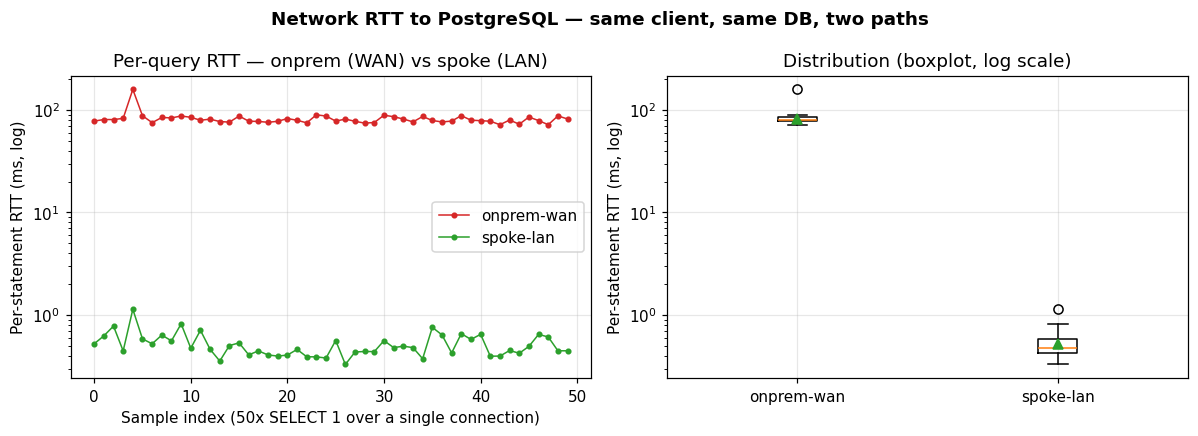

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for env, color in [('onprem-wan', 'tab:red'), ('spoke-lan', 'tab:green')]:
    sub = probe[probe['env_label'] == env]
    axes[0].plot(sub['sample_idx'], sub['rtt_ms'], marker='o',
                 linewidth=1, markersize=3, color=color, label=env)
axes[0].set_yscale('log')
axes[0].set_xlabel('Sample index (50x SELECT 1 over a single connection)')
axes[0].set_ylabel('Per-statement RTT (ms, log)')
axes[0].set_title('Per-query RTT — onprem (WAN) vs spoke (LAN)')
axes[0].legend(loc='best')

data = [probe.loc[probe.env_label == env, 'rtt_ms'].values
        for env in ['onprem-wan', 'spoke-lan']]
axes[1].boxplot(data, tick_labels=['onprem-wan', 'spoke-lan'],
                showmeans=True)
axes[1].set_yscale('log')
axes[1].set_ylabel('Per-statement RTT (ms, log)')
axes[1].set_title('Distribution (boxplot, log scale)')

fig.suptitle('Network RTT to PostgreSQL — same client, same DB, two paths',
             fontweight='bold')
fig.tight_layout()
fig.savefig('fig_01_per_query_rtt.png', bbox_inches='tight')
plt.show()


**Reading the chart**: the WAN line sits on the ≈ 80 ms shelf imposed by
`tc netem`, with the natural ±5 ms jitter we asked for. The LAN line is
two orders of magnitude lower (≈ 0.5 ms median). That ratio — *not* CPU,
*not* disk I/O, *not* PG configuration — is the tax we're about to pay
every single round-trip from the chatty client.


## 2. Application workload duration

Now run the same Python scripts (`chatty.py`, `chunky.py`) on each side
and look at wall-clock duration. Both scripts process **the same 500
items**; the only difference is whether they use N+1 (`chatty`) or a
single set-based statement (`chunky`).


In [4]:
summary = (exp.groupby(['env_label', 'workload'])
             .agg(runs=('run_id', 'count'),
                  avg_roundtrips=('roundtrips', 'mean'),
                  avg_duration_s=('duration_s', 'mean'))
             .round(3)
             .reset_index())
summary


,env_label,workload,runs,avg_roundtrips,avg_duration_s
0,onprem-wan,chatty,3,1003.0,85.458
1,onprem-wan,chunky,3,4.0,1.164
2,spoke-lan,chatty,3,1003.0,2.629
3,spoke-lan,chunky,3,4.0,0.068


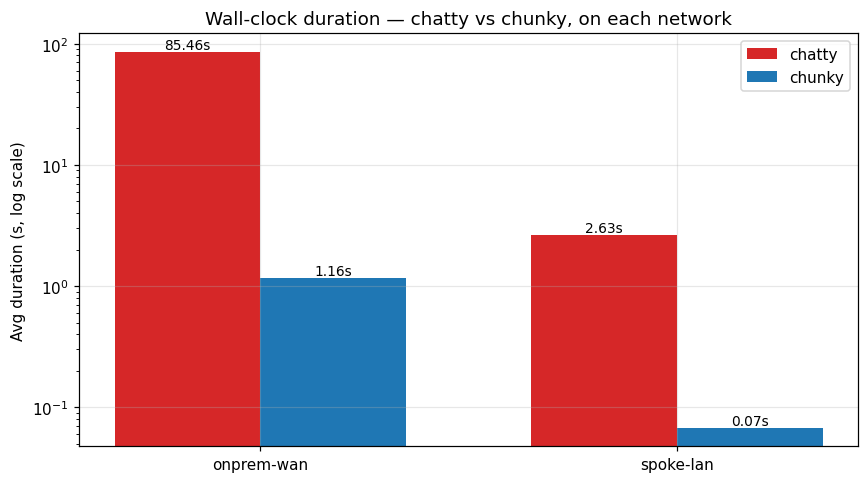

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
envs = ['onprem-wan', 'spoke-lan']
workloads = ['chatty', 'chunky']
x = np.arange(len(envs))
width = 0.35
for i, w in enumerate(workloads):
    vals = [summary.query('env_label==@e and workload==@w')['avg_duration_s'].iloc[0]
            for e in envs]
    bars = ax.bar(x + (i - 0.5) * width, vals, width, label=w,
                  color='tab:red' if w == 'chatty' else 'tab:blue')
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.2f}s',
                ha='center', va='bottom', fontsize=9)
ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels(envs)
ax.set_ylabel('Avg duration (s, log scale)')
ax.set_title('Wall-clock duration — chatty vs chunky, on each network')
ax.legend()
fig.tight_layout()
fig.savefig('fig_02_duration_by_env.png', bbox_inches='tight')
plt.show()


## 3. The WAN tax, made explicit

For each workload, the slowdown when moving from LAN to WAN is **directly
proportional to the number of round-trips × per-query RTT**. We can
verify that empirically:

$$\Delta_{\text{WAN tax}} \approx N_{\text{round-trips}} \times \text{RTT}_{\text{WAN}}$$


In [6]:
lan = summary.query("env_label == 'spoke-lan'").set_index('workload')
wan = summary.query("env_label == 'onprem-wan'").set_index('workload')
extra_s = (wan['avg_duration_s'] - lan['avg_duration_s']).rename('wan_extra_s')
rt = wan['avg_roundtrips']
predicted_extra_s = (rt * 0.080).rename('predicted_extra_s_at_80ms_rtt')
slowdown = (wan['avg_duration_s'] / lan['avg_duration_s']).rename('wan/lan ratio')
compare = pd.concat([rt.rename('roundtrips'), extra_s, predicted_extra_s, slowdown], axis=1)
compare = compare.round(3)
compare


,roundtrips,wan_extra_s,predicted_extra_s_at_80ms_rtt,wan/lan ratio
workload,,,,
chatty,1003.0,82.829,80.24,32.506
chunky,4.0,1.096,0.32,17.118


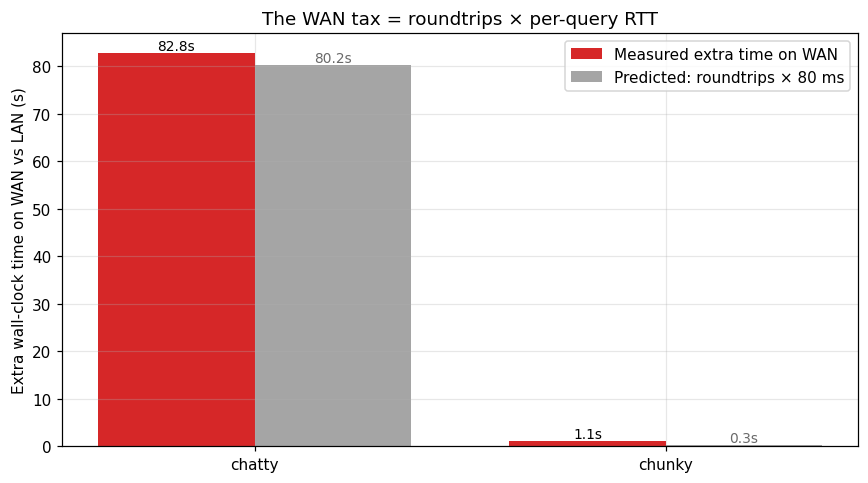

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
wls = compare.index.tolist()
x = np.arange(len(wls))
width = 0.38
ax.bar(x - width/2, compare['wan_extra_s'], width,
       label='Measured extra time on WAN', color='tab:red')
ax.bar(x + width/2, compare['predicted_extra_s_at_80ms_rtt'], width,
       label='Predicted: roundtrips × 80 ms', color='tab:gray', alpha=0.7)
for i, w in enumerate(wls):
    ax.text(i - width/2, compare['wan_extra_s'].iloc[i],
            f"{compare['wan_extra_s'].iloc[i]:.1f}s",
            ha='center', va='bottom', fontsize=9)
    ax.text(i + width/2, compare['predicted_extra_s_at_80ms_rtt'].iloc[i],
            f"{compare['predicted_extra_s_at_80ms_rtt'].iloc[i]:.1f}s",
            ha='center', va='bottom', fontsize=9, color='dimgray')
ax.set_xticks(x)
ax.set_xticklabels(wls)
ax.set_ylabel('Extra wall-clock time on WAN vs LAN (s)')
ax.set_title('The WAN tax = roundtrips × per-query RTT')
ax.legend()
fig.tight_layout()
fig.savefig('fig_03_wan_tax_prediction.png', bbox_inches='tight')
plt.show()


Read the table:
- `chatty`: 1003 round-trips × 80 ms ≈ **80 s** of pure WAN wait. The
  measured extra time matches that prediction within a few seconds (the
  rest is client-side CPU + PG server CPU).
- `chunky`: 4 round-trips × 80 ms ≈ **0.32 s** of WAN wait. Same logical
  work, but only 4 trips because it uses a single set-based
  `INSERT … SELECT … LIMIT`.

That's the headline of the lab: **chunky pays the tax 4 times, chatty
pays it 1003 times.** The DB is identical in both cases.


## 4. Run-by-run consistency

Always look at variance — a single number can lie. Below is each
individual run, so you can convince yourself the means above aren't an
artifact of one outlier.


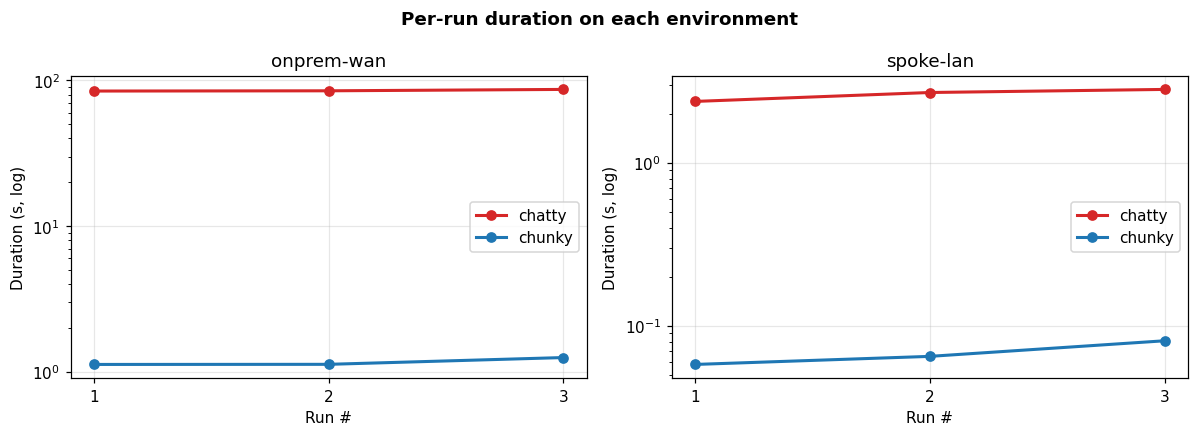

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
for ax, env in zip(axes, ['onprem-wan', 'spoke-lan']):
    sub = exp[exp.env_label == env].copy()
    sub = sub.sort_values(['workload', 'duration_s']).reset_index(drop=True)
    sub['order'] = sub.groupby('workload').cumcount() + 1
    for w, color in [('chatty', 'tab:red'), ('chunky', 'tab:blue')]:
        s = sub[sub.workload == w]
        ax.plot(s['order'], s['duration_s'], marker='o', linewidth=2,
                label=w, color=color)
    ax.set_yscale('log')
    ax.set_xticks([1, 2, 3])
    ax.set_xlabel('Run #')
    ax.set_ylabel('Duration (s, log)')
    ax.set_title(env)
    ax.legend()
fig.suptitle('Per-run duration on each environment',
             fontweight='bold')
fig.tight_layout()
fig.savefig('fig_04_per_run_duration.png', bbox_inches='tight')
plt.show()


## 5. The single chart that summarises it all

Put round-trips on the x-axis and duration on the y-axis (log-log) and
the relationship is a line whose slope is exactly the per-query RTT.
Two points per environment — chatty (top-right) and chunky (bottom-left)
— land on two parallel lines, separated vertically by the LAN-vs-WAN
gap.


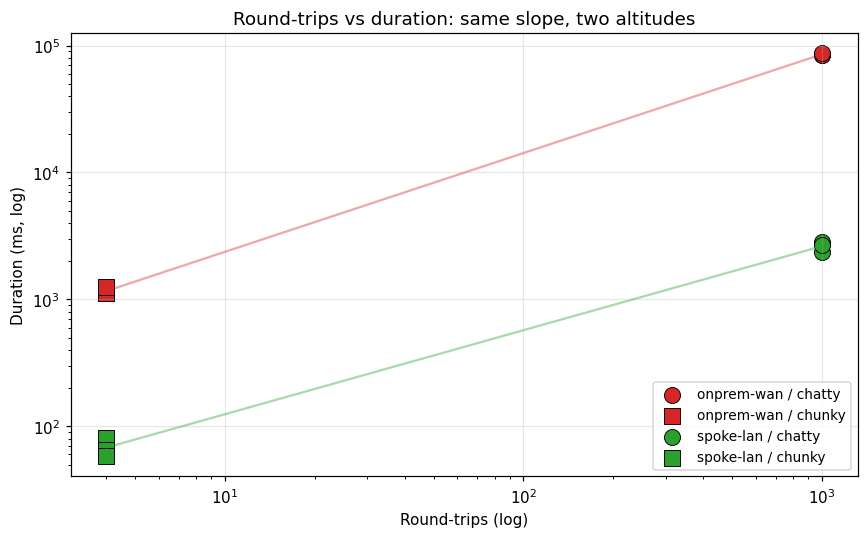

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = {'onprem-wan': 'tab:red', 'spoke-lan': 'tab:green'}
markers = {'chatty': 'o', 'chunky': 's'}
for env in ['onprem-wan', 'spoke-lan']:
    for w in ['chatty', 'chunky']:
        s = exp[(exp.env_label == env) & (exp.workload == w)]
        ax.scatter(s['roundtrips'], s['duration_ms'], s=110,
                   marker=markers[w], edgecolor='black', linewidth=0.6,
                   color=colors[env], label=f'{env} / {w}')
    # connect the two means with a thin line per env to show the slope
    g = (exp[exp.env_label == env]
         .groupby('workload')
         .agg(rt=('roundtrips', 'mean'), dur=('duration_ms', 'mean')))
    g = g.sort_values('rt')
    ax.plot(g['rt'], g['dur'], color=colors[env], alpha=0.4, linewidth=1.5)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Round-trips (log)')
ax.set_ylabel('Duration (ms, log)')
ax.set_title('Round-trips vs duration: same slope, two altitudes')
ax.legend(loc='lower right', fontsize=9)
fig.tight_layout()
fig.savefig('fig_05_scatter_log_log.png', bbox_inches='tight')
plt.show()


## 6. Take-aways

1. **Latency is per round-trip, not per byte.** Bandwidth is irrelevant
   here — even on a fat ExpressRoute link, 1003 sequential queries
   *cannot* finish in under `1003 × RTT`.
2. **The fix is set-based work, not a faster network.** Moving from
   chatty to chunky on the same WAN already shaves the cost down to a
   handful of round-trips.
3. **Same workload on the LAN side proves the DB and CPU are not the
   bottleneck** — chatty over LAN finishes in ≈ 2.6 s, the WAN version in
   ≈ 85 s. The only thing that changed is the path.
4. **You can predict the WAN tax from first principles.** Pick up the
   per-query RTT from the latency probe (or from Network Watcher
   Connection Monitor) and multiply by the round-trip count of the
   batch. Match that against measured duration; the gap is
   client/server CPU.

If you want to reproduce: bring up the lab with `infra/deploy.sh`, run
the experiments with `scripts/run_experiments.sh` from each VM, run the
probe with `scripts/latency_probe.py`, then re-run this notebook.
